# Exploratory Data Analysis

Notebook ini merangkum Chapter 1 dari *Practical Statistics for Data Scientists* edisi kedua. Chapter ini membahas **Exploratory Data Analysis (EDA)** sebagai tahap awal dalam proyek data science, yaitu proses memahami struktur data, meringkas data dengan statistik deskriptif, dan memvisualisasikan pola data sebelum melakukan pemodelan.

Pembahasan dibuat mengikuti format notebook sebelumnya: terdapat tujuan pembelajaran, ringkasan chapter, struktur pembahasan, penjelasan teori per bagian, rumus matematis yang relevan, contoh kode inti, ringkasan konsep, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami peran Exploratory Data Analysis dalam proyek data science.
- Membedakan jenis data terstruktur, seperti numeric, categorical, binary, dan ordinal.
- Memahami rectangular data sebagai struktur utama dalam analisis data.
- Menghitung estimates of location, seperti mean, median, trimmed mean, dan weighted mean.
- Menghitung estimates of variability, seperti variance, standard deviation, MAD, percentile, dan IQR.
- Mengeksplorasi distribusi data menggunakan percentiles, boxplot, histogram, dan density plot.
- Mengeksplorasi data binary dan categorical menggunakan proportions, bar chart, mode, expected value, dan probability.
- Menghitung dan menafsirkan correlation antara dua variabel numeric.
- Memvisualisasikan hubungan dua atau lebih variabel menggunakan scatterplot, hexagonal binning, contingency table, boxplot, dan visualisasi multivariat.

## Ringkasan Chapter

Chapter ini menjelaskan bahwa Exploratory Data Analysis merupakan langkah awal dalam proyek data science. EDA digunakan untuk memahami data sebelum proses modeling dilakukan. Fokus utamanya adalah melihat struktur data, tipe data, ringkasan statistik, distribusi nilai, hubungan antar variabel, serta kemungkinan adanya outlier atau pola yang perlu diperhatikan.

Pembahasan dimulai dari jenis data terstruktur. Data numeric dibagi menjadi continuous dan discrete, sedangkan data categorical mencakup binary dan ordinal. Identifikasi jenis data penting karena menentukan cara visualisasi, pemrosesan, dan pemodelan statistik yang tepat.

Chapter ini juga menjelaskan rectangular data sebagai bentuk data yang paling umum digunakan dalam data science. Rectangular data berbentuk tabel, dengan rows sebagai records atau observations, dan columns sebagai features atau variables. Bentuk ini menjadi dasar bagi banyak metode statistik dan machine learning.

Bagian berikutnya membahas estimates of location dan variability. Mean adalah ukuran lokasi yang paling umum, tetapi sensitif terhadap outlier. Median dan trimmed mean lebih robust terhadap nilai ekstrem. Untuk variability, standard deviation dan variance sering digunakan, tetapi keduanya juga sensitif terhadap outlier. Alternatif yang lebih robust adalah median absolute deviation dan interquartile range.

Chapter ini kemudian membahas distribusi data melalui percentiles, boxplots, histograms, dan density plots. Untuk categorical data, eksplorasi dilakukan melalui proportions, bar charts, mode, expected value, dan probability. Pada bagian akhir, chapter membahas correlation, scatterplots, dan eksplorasi dua atau lebih variabel menggunakan visualisasi seperti hexagonal binning, contour plot, contingency table, dan boxplot per kategori.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Elements of Structured Data | Jenis data utama dalam data science: numeric, categorical, binary, dan ordinal. |
| Rectangular Data | Struktur data tabel dengan rows sebagai records dan columns sebagai features. |
| Estimates of Location | Ukuran nilai tipikal data, seperti mean, median, trimmed mean, dan weighted mean. |
| Estimates of Variability | Ukuran penyebaran data, seperti variance, standard deviation, MAD, percentile, dan IQR. |
| Exploring the Data Distribution | Distribusi data dieksplorasi melalui percentiles, boxplot, histogram, dan density plot. |
| Exploring Binary and Categorical Data | Data categorical diringkas melalui proportions, bar chart, mode, expected value, dan probability. |
| Correlation | Mengukur hubungan linear antara dua variabel numeric. |
| Exploring Two or More Variables | Eksplorasi bivariate dan multivariate menggunakan scatterplot, hexbin, contingency table, dan boxplot. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import trim_mean

np.random.seed(2024)

## Elements of Structured Data

Data dalam data science dapat berasal dari berbagai sumber, seperti sensor, events, text, images, videos, dan clickstreams. Banyak data awal bersifat unstructured, sehingga perlu diproses menjadi bentuk structured data agar dapat dianalisis secara statistik.

Chapter ini membagi structured data menjadi dua kelompok besar: **numeric** dan **categorical**. Numeric data dapat berupa continuous atau discrete, sedangkan categorical data dapat berupa binary atau ordinal. Tipe data penting karena memengaruhi cara software memperlakukan data, cara visualisasi dibuat, dan model statistik yang sesuai.

## Jenis Data Terstruktur

| Jenis Data | Penjelasan | Contoh |
|---|---|---|
| Numeric | Data yang dinyatakan dalam skala angka. | Harga, umur, durasi |
| Continuous | Numeric data yang dapat mengambil nilai apa pun dalam interval. | Kecepatan angin, waktu |
| Discrete | Numeric data yang hanya mengambil nilai integer. | Jumlah klik, jumlah pembelian |
| Categorical | Data yang hanya memiliki sejumlah kategori tertentu. | Jenis layar, nama negara bagian |
| Binary | Categorical data dengan dua kemungkinan nilai. | Ya/tidak, 0/1, true/false |
| Ordinal | Categorical data yang memiliki urutan eksplisit. | Rating 1–5, tingkat kepuasan |

In [2]:
data_types = pd.DataFrame({
    "variable": ["price", "click_count", "screen_type", "is_member", "rating"],
    "example_value": [125000, 7, "LED", True, 4],
    "data_type": ["continuous", "discrete", "categorical", "binary", "ordinal"]
})

data_types

,variable,example_value,data_type
0,price,125000,continuous
1,click_count,7,discrete
2,screen_type,LED,categorical
3,is_member,True,binary
4,rating,4,ordinal


## Rectangular Data

Rectangular data adalah struktur data dua dimensi berbentuk tabel. Rows merepresentasikan records, cases, instances, samples, atau observations. Columns merepresentasikan features, variables, attributes, predictors, atau inputs.

Dalam Python, bentuk rectangular data paling umum adalah `pandas.DataFrame`. Struktur ini menjadi dasar untuk analisis statistik dan model machine learning.

## Terminologi Rectangular Data

| Istilah | Makna |
|---|---|
| Data frame | Struktur data berbentuk tabel seperti spreadsheet. |
| Feature | Column dalam tabel yang berisi variabel pengamatan. |
| Outcome | Variabel yang ingin diprediksi atau dijelaskan. |
| Record | Row dalam tabel yang mewakili satu observasi. |
| Index | Penanda baris yang dapat membantu akses dan operasi data. |

In [3]:
auction = pd.DataFrame({
    "Category": ["Music/Movie/Game", "Automotive", "Automotive", "Electronics"],
    "currency": ["US", "US", "US", "US"],
    "sellerRating": [3249, 3115, 3115, 5800],
    "Duration": [5, 7, 7, 3],
    "ClosePrice": [0.01, 0.01, 0.01, 12.50],
    "OpenPrice": [0.01, 0.01, 0.01, 5.00],
    "Competitive": [0, 0, 1, 1]
})

auction

,Category,currency,sellerRating,Duration,ClosePrice,OpenPrice,Competitive
0,Music/Movie/Game,US,3249,5,0.01,0.01,0
1,Automotive,US,3115,7,0.01,0.01,0
2,Automotive,US,3115,7,0.01,0.01,1
3,Electronics,US,5800,3,12.50,5.00,1


## Nonrectangular Data Structures

Selain rectangular data, chapter juga menyebut beberapa struktur data lain:

| Struktur Data | Penjelasan |
|---|---|
| Time series | Data berisi pengukuran berurutan terhadap variabel yang sama. |
| Spatial data | Data yang berkaitan dengan lokasi, koordinat, atau area. |
| Graph/network data | Data yang menggambarkan hubungan antar entitas. |

Meskipun struktur ini penting, fokus buku berada pada rectangular data karena bentuk tersebut menjadi dasar utama predictive modeling.

## Estimates of Location

Estimates of location digunakan untuk menentukan nilai tipikal dari suatu variabel. Nilai ini menggambarkan di mana sebagian besar data berada.

Ukuran lokasi yang paling umum adalah mean. Namun, mean dapat terpengaruh oleh outlier. Oleh karena itu, median, trimmed mean, weighted mean, dan weighted median digunakan sebagai alternatif dalam kondisi tertentu.

## Rumus Mean

Mean adalah jumlah seluruh nilai dibagi jumlah data.

$$
\bar{x} =
\frac{
\sum_{i=1}^{n}x_i
}{n}
$$

Keterangan:

- $\bar{x}$ = mean atau rata-rata
- $x_i$ = nilai data ke-$i$
- $n$ = jumlah data

Mean mudah dihitung, tetapi sensitif terhadap nilai ekstrem.

## Rumus Trimmed Mean

Trimmed mean dihitung dengan membuang sejumlah nilai paling kecil dan paling besar, lalu menghitung rata-rata dari sisa data.

$$
\bar{x} =
\frac{
\sum_{i=p+1}^{n-p}x_{(i)}
}{n-2p}
$$

Keterangan:

- $x_{(i)}$ = data yang sudah diurutkan
- $p$ = jumlah nilai yang dibuang dari masing-masing ujung
- $n$ = jumlah data awal

Trimmed mean lebih robust dibanding mean biasa karena pengaruh outlier dikurangi.

## Rumus Weighted Mean

Weighted mean digunakan ketika setiap data memiliki bobot yang berbeda.

$$
\bar{x}_w =
\frac{
\sum_{i=1}^{n}w_ix_i
}{
\sum_{i=1}^{n}w_i
}
$$

Keterangan:

- $\bar{x}_w$ = weighted mean
- $w_i$ = bobot untuk data ke-$i$
- $x_i$ = nilai data ke-$i$

Weighted mean berguna ketika beberapa observasi lebih penting atau lebih representatif dibanding observasi lain.

In [4]:
values = np.array([3, 5, 1, 2])
weights = np.array([1, 1, 2, 1])

mean_value = np.mean(values)
trimmed_mean_value = trim_mean(values, proportiontocut=0.25)
median_value = np.median(values)
weighted_mean_value = np.average(values, weights=weights)

print("Mean:", mean_value)
print("Trimmed mean:", trimmed_mean_value)
print("Median:", median_value)
print("Weighted mean:", weighted_mean_value)

Mean: 2.75
Trimmed mean: 2.5
Median: 2.5
Weighted mean: 2.4


## Median dan Robust Estimates

Median adalah nilai tengah setelah data diurutkan. Jika jumlah data genap, median dihitung sebagai rata-rata dua nilai tengah. Median disebut robust estimate karena tidak banyak dipengaruhi oleh outlier.

Contoh penting pada chapter adalah data pendapatan atau populasi. Jika terdapat satu nilai yang sangat besar, mean dapat berubah drastis, sedangkan median tetap lebih stabil.

In [5]:
income = np.array([45, 50, 52, 48, 49, 51, 47, 500])

print("Mean with outlier:", np.mean(income))
print("Median with outlier:", np.median(income))

income_without_outlier = income[income < 100]

print("\nMean without outlier:", np.mean(income_without_outlier))
print("Median without outlier:", np.median(income_without_outlier))

Mean with outlier: 105.25
Median with outlier: 49.5

Mean without outlier: 48.857142857142854
Median without outlier: 49.0


## Estimates of Variability

Variability atau dispersion mengukur seberapa tersebar nilai data. Dua dataset dapat memiliki mean yang sama, tetapi penyebaran yang berbeda. Dalam statistik, variability sangat penting karena data nyata hampir selalu mengandung variasi.

Ukuran variability yang dibahas pada chapter meliputi deviations, variance, standard deviation, mean absolute deviation, median absolute deviation, range, percentiles, dan interquartile range.

## Rumus Mean Absolute Deviation

Mean absolute deviation menghitung rata-rata nilai absolut dari deviasi terhadap mean.

$$
\text{Mean absolute deviation}
=
\frac{
\sum_{i=1}^{n}|x_i-\bar{x}|
}{n}
$$

Keterangan:

- $x_i$ = nilai data ke-$i$
- $\bar{x}$ = mean
- $n$ = jumlah data

Nilai absolut digunakan agar deviasi negatif dan positif tidak saling menghapus.

## Rumus Variance dan Standard Deviation

Variance adalah rata-rata squared deviations dari mean, dengan denominator $n-1$ untuk sample variance.

$$
s^2 =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})^2
}{n-1}
$$

Standard deviation adalah akar dari variance.

$$
s = \sqrt{s^2}
$$

Keterangan:

- $s^2$ = sample variance
- $s$ = standard deviation
- $\bar{x}$ = mean
- $n$ = jumlah data

Standard deviation lebih mudah ditafsirkan dibanding variance karena berada pada skala yang sama dengan data asli.

## Rumus Median Absolute Deviation

Median absolute deviation from the median atau MAD adalah ukuran variability yang robust terhadap outlier.

$$
MAD =
\text{Median}
\left(
|x_1-m|,
|x_2-m|,
\ldots,
|x_n-m|
\right)
$$

Keterangan:

- $m$ = median data
- $x_i$ = nilai data ke-$i$

MAD lebih stabil terhadap nilai ekstrem dibanding variance dan standard deviation.

In [6]:
population = np.array([
    4779736, 710231, 6392017, 2915918, 37253956,
    5029196, 3574097, 897934, 18801310, 9687653,
    1360301, 1567582, 12830632, 6483802, 3046355
])

std_pop = np.std(population, ddof=1)
iqr_pop = np.percentile(population, 75) - np.percentile(population, 25)
mad_pop = stats.median_abs_deviation(population, scale=1)

print("Standard deviation:", round(std_pop, 2))
print("IQR:", round(iqr_pop, 2))
print("MAD:", round(mad_pop, 2))

Standard deviation: 9562908.12
IQR: 5843977.5
MAD: 3212154.0


## Estimates Based on Percentiles

Percentile adalah nilai yang menunjukkan bahwa sejumlah persentase data berada di bawah atau sama dengan nilai tersebut. Median adalah percentile ke-50.

Interquartile range atau IQR adalah selisih antara percentile ke-75 dan percentile ke-25.

### Rumus IQR

$$
IQR = Q_3 - Q_1
$$

Keterangan:

- $Q_1$ = percentile ke-25
- $Q_3$ = percentile ke-75
- $IQR$ = interquartile range

IQR robust terhadap outlier karena hanya menggunakan bagian tengah distribusi.

In [7]:
murder_rate = np.array([
    5.7, 5.6, 4.7, 5.6, 4.4, 2.8, 2.4, 5.8,
    5.8, 5.7, 1.8, 2.0, 5.3, 4.9, 1.9
])

percentiles = np.percentile(murder_rate, [5, 25, 50, 75, 95])

pd.DataFrame({
    "Percentile": ["5%", "25%", "50%", "75%", "95%"],
    "Murder Rate": percentiles
})

,Percentile,Murder Rate
0,5%,1.87
1,25%,2.60
2,50%,4.90
3,75%,5.65
4,95%,5.80


## Exploring the Data Distribution

Satu angka seperti mean atau standard deviation tidak cukup untuk menggambarkan keseluruhan bentuk distribusi. Oleh karena itu, chapter membahas visualisasi distribusi seperti boxplot, frequency table, histogram, dan density plot.

Visualisasi distribusi membantu melihat skewness, outlier, konsentrasi nilai, serta pola yang mungkin tidak terlihat dari ringkasan angka.

## Percentiles dan Boxplots

Boxplot adalah visualisasi distribusi yang diperkenalkan oleh Tukey. Elemen umum boxplot:

| Elemen | Makna |
|---|---|
| Garis tengah box | Median |
| Batas bawah box | Percentile ke-25 |
| Batas atas box | Percentile ke-75 |
| Whiskers | Rentang utama data |
| Titik di luar whiskers | Kemungkinan outlier |

Boxplot berguna untuk melihat distribusi dan outlier secara cepat.

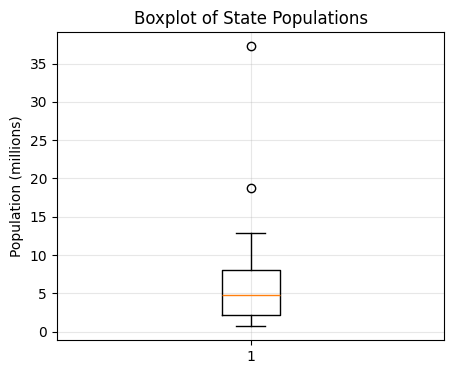

In [8]:
plt.figure(figsize=(5, 4))
plt.boxplot(population / 1_000_000, vert=True)
plt.ylabel("Population (millions)")
plt.title("Boxplot of State Populations")
plt.grid(alpha=0.3)
plt.show()

## Frequency Tables dan Histograms

Frequency table membagi rentang nilai numeric menjadi beberapa interval atau bins, lalu menghitung jumlah data pada setiap bin. Histogram menampilkan frequency table dalam bentuk grafik.

Karakteristik histogram:

- bins memiliki lebar yang sama,
- bars biasanya saling menempel,
- jumlah bins ditentukan oleh pengguna,
- empty bins tetap dapat ditampilkan.

In [9]:
counts, bin_edges = np.histogram(population / 1_000_000, bins=6)

freq_table = pd.DataFrame({
    "bin_start": bin_edges[:-1],
    "bin_end": bin_edges[1:],
    "count": counts
})

freq_table

,bin_start,bin_end,count
0,0.710231,6.800852,11
1,6.800852,12.891473,2
2,12.891473,18.982094,1
3,18.982094,25.072714,0
4,25.072714,31.163335,0
5,31.163335,37.253956,1


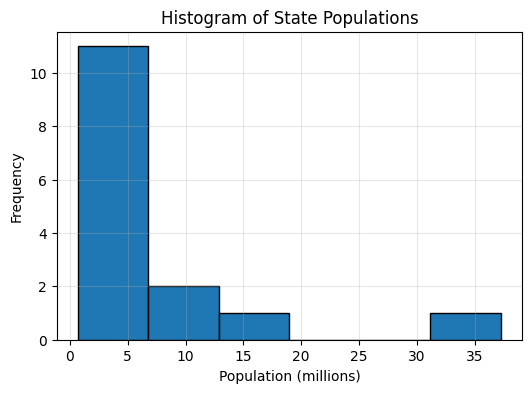

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(population / 1_000_000, bins=6, edgecolor="black")
plt.xlabel("Population (millions)")
plt.ylabel("Frequency")
plt.title("Histogram of State Populations")
plt.grid(alpha=0.3)
plt.show()

## Density Plots

Density plot adalah versi halus dari histogram. Plot ini sering dihitung menggunakan kernel density estimate. Density plot berguna untuk melihat bentuk distribusi secara lebih kontinu.

Perbedaan utama histogram dan density plot adalah histogram menampilkan jumlah data dalam bins, sedangkan density plot menampilkan estimasi kurva distribusi.

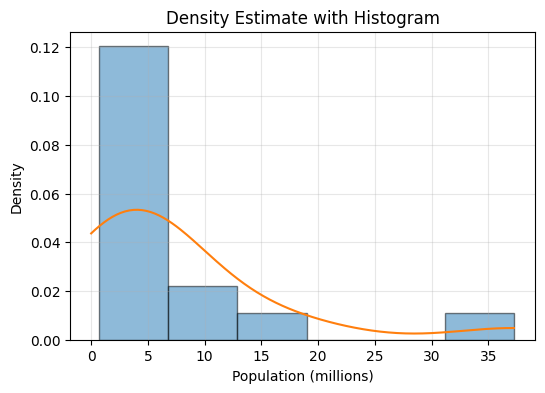

In [11]:
density = stats.gaussian_kde(population / 1_000_000)
x_grid = np.linspace(0, max(population / 1_000_000), 200)

plt.figure(figsize=(6, 4))
plt.hist(population / 1_000_000, bins=6, density=True, alpha=0.5, edgecolor="black")
plt.plot(x_grid, density(x_grid))
plt.xlabel("Population (millions)")
plt.ylabel("Density")
plt.title("Density Estimate with Histogram")
plt.grid(alpha=0.3)
plt.show()

## Exploring Binary and Categorical Data

Untuk data categorical, ringkasan yang paling umum adalah jumlah atau proporsi setiap kategori. Visualisasi yang sering digunakan adalah bar chart.

Bar chart berbeda dari histogram. Bar chart digunakan untuk categories, sedangkan histogram digunakan untuk numeric data yang dibagi ke dalam bins.

## Mode, Expected Value, dan Probability

Mode adalah kategori atau nilai yang paling sering muncul.

Expected value digunakan ketika kategori memiliki nilai numeric yang dapat dikalikan dengan probability kemunculannya.

### Rumus Expected Value

$$
EV =
\sum_{i=1}^{n}p_ix_i
$$

Keterangan:

- $EV$ = expected value
- $p_i$ = probability kategori ke-$i$
- $x_i$ = nilai numeric kategori ke-$i$

Probability adalah peluang suatu kejadian terjadi, biasanya dihitung sebagai proporsi jumlah kejadian terhadap total kejadian.

In [12]:
delay_causes = pd.Series({
    "Carrier": 23.02,
    "ATC": 30.40,
    "Weather": 4.03,
    "Security": 0.12,
    "Inbound": 42.43
})

delay_causes

Carrier     23.02
ATC         30.40
Weather      4.03
Security     0.12
Inbound     42.43
dtype: float64

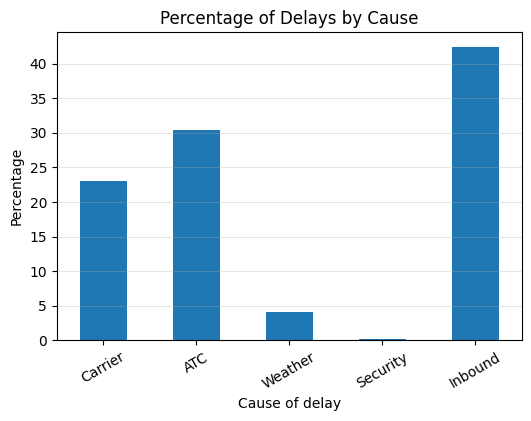

In [13]:
plt.figure(figsize=(6, 4))
delay_causes.plot(kind="bar")
plt.xlabel("Cause of delay")
plt.ylabel("Percentage")
plt.title("Percentage of Delays by Cause")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Correlation

Correlation coefficient mengukur hubungan linear antara dua variabel numeric. Nilainya berada pada rentang $-1$ sampai $+1$.

Interpretasi umum:

- $+1$ menunjukkan positive correlation sempurna.
- $-1$ menunjukkan negative correlation sempurna.
- $0$ menunjukkan tidak ada hubungan linear.

Correlation bernilai nol tidak selalu berarti tidak ada hubungan sama sekali, karena hubungan nonlinear dapat tetap terjadi meskipun correlation linear mendekati nol.

## Rumus Pearson Correlation

Pearson correlation coefficient ditulis sebagai:

$$
r =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
(n-1)s_xs_y
}
$$

Keterangan:

- $r$ = Pearson correlation coefficient
- $x_i$ dan $y_i$ = pasangan nilai data
- $\bar{x}$ dan $\bar{y}$ = mean masing-masing variabel
- $s_x$ dan $s_y$ = standard deviation masing-masing variabel
- $n$ = jumlah pasangan data

Correlation merupakan metric yang sudah distandardisasi, sehingga tidak bergantung langsung pada skala satuan awal.

In [14]:
n = 754
att = np.random.normal(0, 1, n)
verizon = 0.55 * att + np.random.normal(0, 0.8, n)

returns = pd.DataFrame({
    "ATT": att,
    "Verizon": verizon
})

corr_value = returns["ATT"].corr(returns["Verizon"])

print("Correlation:", round(corr_value, 3))

Correlation: 0.587


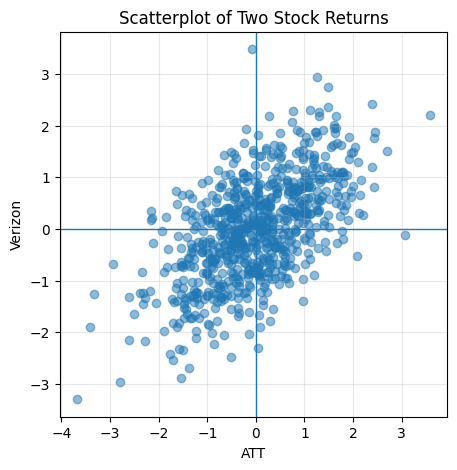

In [15]:
plt.figure(figsize=(5, 5))
plt.scatter(returns["ATT"], returns["Verizon"], alpha=0.5)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("ATT")
plt.ylabel("Verizon")
plt.title("Scatterplot of Two Stock Returns")
plt.grid(alpha=0.3)
plt.show()

## Correlation Matrix

Correlation matrix digunakan untuk melihat hubungan antar banyak variabel numeric sekaligus. Nilai diagonal selalu 1 karena setiap variabel berkorelasi sempurna dengan dirinya sendiri.

Correlation matrix sering divisualisasikan menggunakan heatmap agar pola hubungan antar variabel lebih mudah terlihat.

In [16]:
stock_returns = pd.DataFrame({
    "T": att,
    "VZ": verizon,
    "SP500": 0.4*att + np.random.normal(0, 1, n),
    "DOW": 0.5*verizon + np.random.normal(0, 1, n),
    "MSFT": np.random.normal(0, 1, n)
})

corr_matrix = stock_returns.corr()

corr_matrix

,T,VZ,SP500,DOW,MSFT
T,1.000000,0.587169,0.347696,0.240739,-0.025401
VZ,0.587169,1.000000,0.161600,0.410014,-0.023125
SP500,0.347696,0.161600,1.000000,0.065125,0.046011
DOW,0.240739,0.410014,0.065125,1.000000,-0.021303
MSFT,-0.025401,-0.023125,0.046011,-0.021303,1.000000


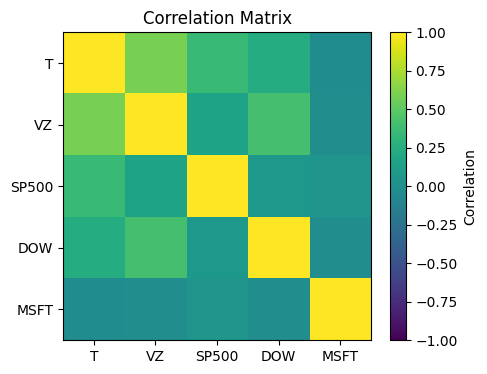

In [17]:
plt.figure(figsize=(5, 4))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

## Exploring Two or More Variables

Univariate analysis melihat satu variabel, bivariate analysis melihat dua variabel, sedangkan multivariate analysis melihat lebih dari dua variabel. Jenis visualisasi yang digunakan bergantung pada tipe variabel:

| Kombinasi Variabel | Visualisasi Umum |
|---|---|
| Numeric vs numeric | Scatterplot, hexagonal binning, contour plot |
| Categorical vs categorical | Contingency table |
| Categorical vs numeric | Boxplot atau violin plot |
| Multiple variables | Faceting, grouping, atau color encoding |

## Hexagonal Binning untuk Numeric vs Numeric

Scatterplot dapat terlalu padat ketika jumlah data sangat besar. Hexagonal binning mengelompokkan data ke dalam bins berbentuk hexagon, lalu menunjukkan jumlah data pada setiap bin menggunakan intensitas warna.

Teknik ini berguna untuk melihat pola hubungan dua variabel numeric pada dataset besar.

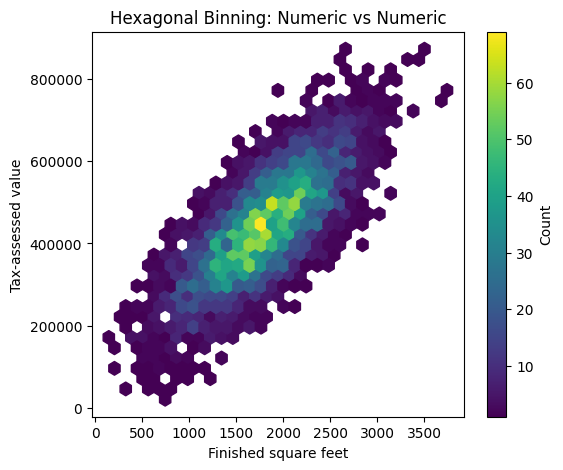

In [18]:
N = 5000
sqft = np.random.normal(1800, 500, N)
tax_value = 120000 + sqft * 180 + np.random.normal(0, 80000, N)

housing = pd.DataFrame({
    "SqFtTotLiving": sqft,
    "TaxAssessedValue": tax_value
})

plt.figure(figsize=(6, 5))
plt.hexbin(
    housing["SqFtTotLiving"],
    housing["TaxAssessedValue"],
    gridsize=30,
    mincnt=1
)
plt.colorbar(label="Count")
plt.xlabel("Finished square feet")
plt.ylabel("Tax-assessed value")
plt.title("Hexagonal Binning: Numeric vs Numeric")
plt.show()

## Two Categorical Variables

Hubungan antara dua categorical variables dapat diringkas menggunakan contingency table. Tabel ini menghitung jumlah data untuk setiap kombinasi kategori.

Dalam Python, contingency table dapat dibuat menggunakan `pd.crosstab()` atau `pivot_table()`.

In [19]:
loans = pd.DataFrame({
    "grade": np.random.choice(list("ABCDEFG"), size=500, p=[0.12, 0.18, 0.20, 0.18, 0.14, 0.10, 0.08]),
    "status": np.random.choice(["Fully Paid", "Charged Off", "Late"], size=500, p=[0.72, 0.20, 0.08])
})

crosstab = pd.crosstab(loans["grade"], loans["status"], margins=True)
crosstab

status,Charged Off,Fully Paid,Late,All
grade,,,,
A,11,39,4,54
B,20,67,6,93
C,13,72,8,93
D,16,66,7,89
E,10,51,9,70
F,12,51,4,67
G,7,25,2,34
All,89,371,40,500


## Categorical and Numeric Data

Boxplot dapat digunakan untuk membandingkan distribusi numeric variable berdasarkan kategori tertentu. Contohnya, persentase delay penerbangan dapat dibandingkan antar airline.

Boxplot per kategori membantu melihat perbedaan median, IQR, outlier, dan penyebaran antar kelompok.

<Figure size 700x400 with 0 Axes>

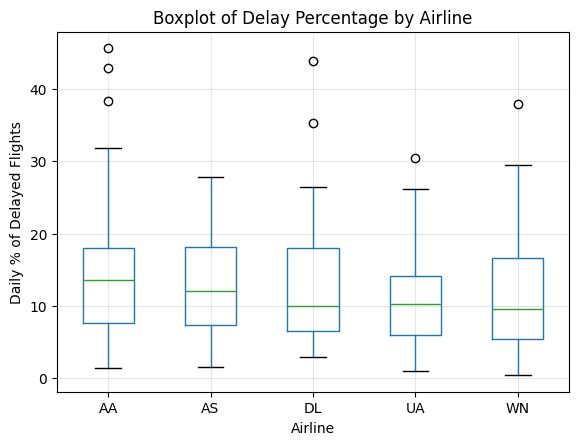

In [20]:
airline_stats = pd.DataFrame({
    "airline": np.random.choice(["AA", "AS", "DL", "UA", "WN"], size=250),
    "pct_carrier_delay": np.clip(np.random.gamma(shape=2, scale=6, size=250), 0, 50)
})

plt.figure(figsize=(7, 4))
airline_stats.boxplot(column="pct_carrier_delay", by="airline")
plt.xlabel("Airline")
plt.ylabel("Daily % of Delayed Flights")
plt.title("Boxplot of Delay Percentage by Airline")
plt.suptitle("")
plt.grid(alpha=0.3)
plt.show()

## Visualizing Multiple Variables

Untuk menampilkan lebih dari dua variabel, visualisasi dapat menambahkan dimensi melalui warna, panel, ukuran titik, atau bentuk marker. Chapter memberi contoh penggunaan conditioning/faceting untuk membandingkan hubungan antar variabel berdasarkan kategori.

Prinsip utamanya adalah visualisasi multivariat harus tetap mudah dibaca. Jika terlalu banyak variabel dimasukkan sekaligus, plot dapat menjadi sulit ditafsirkan.

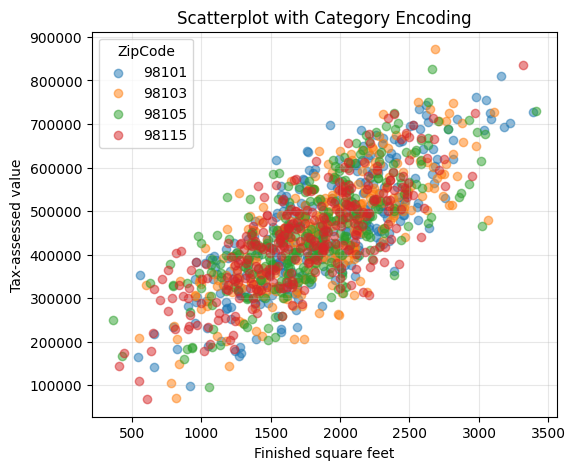

In [21]:
housing["ZipCode"] = np.random.choice(["98101", "98103", "98105", "98115"], size=N)

plt.figure(figsize=(6, 5))
for zipcode, group in housing.groupby("ZipCode"):
    sample = group.sample(min(300, len(group)), random_state=2024)
    plt.scatter(
        sample["SqFtTotLiving"],
        sample["TaxAssessedValue"],
        alpha=0.5,
        label=zipcode
    )

plt.xlabel("Finished square feet")
plt.ylabel("Tax-assessed value")
plt.title("Scatterplot with Category Encoding")
plt.legend(title="ZipCode")
plt.grid(alpha=0.3)
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Exploratory Data Analysis | Tahap awal untuk memahami struktur, distribusi, dan hubungan dalam data. |
| Structured data | Data yang sudah memiliki bentuk terorganisasi, misalnya tabel. |
| Numeric data | Data berskala angka, mencakup continuous dan discrete. |
| Categorical data | Data berupa kategori tetap, mencakup binary dan ordinal. |
| Rectangular data | Data berbentuk tabel dengan rows sebagai records dan columns sebagai features. |
| Mean | Ukuran lokasi paling umum, tetapi sensitif terhadap outlier. |
| Median | Ukuran lokasi robust yang menggunakan nilai tengah data. |
| Trimmed mean | Mean setelah nilai ekstrem dihapus dari kedua ujung. |
| Weighted mean | Mean yang memperhitungkan bobot tiap observasi. |
| Standard deviation | Ukuran penyebaran data pada skala asli. |
| MAD | Ukuran variability robust berdasarkan median. |
| Percentile | Nilai yang menunjukkan posisi tertentu dalam distribusi. |
| IQR | Selisih percentile ke-75 dan ke-25. |
| Boxplot | Visualisasi distribusi berbasis quartiles dan outlier. |
| Histogram | Visualisasi frequency table untuk numeric data. |
| Density plot | Estimasi distribusi halus dari data numeric. |
| Bar chart | Visualisasi frekuensi atau proporsi kategori. |
| Correlation | Ukuran hubungan linear antara dua variabel numeric. |
| Scatterplot | Visualisasi hubungan antara dua variabel numeric. |
| Hexbin | Alternatif scatterplot untuk data berukuran besar. |
| Contingency table | Tabel hitung untuk dua categorical variables. |

## Kesimpulan Chapter

Chapter ini menekankan bahwa Exploratory Data Analysis merupakan tahap penting sebelum melakukan pemodelan. EDA membantu memahami tipe data, struktur data, distribusi, outlier, dan hubungan antar variabel.

Structured data dibagi menjadi numeric dan categorical. Numeric data dapat berupa continuous atau discrete, sedangkan categorical data dapat berupa binary atau ordinal. Pemahaman tipe data penting karena menentukan cara analisis, visualisasi, dan pemodelan yang sesuai.

Rectangular data menjadi bentuk utama dalam data science, dengan rows sebagai observations dan columns sebagai features. Bentuk ini digunakan oleh banyak metode statistik dan machine learning.

Estimates of location seperti mean, median, trimmed mean, dan weighted mean digunakan untuk menggambarkan nilai tipikal data. Estimates of variability seperti standard deviation, variance, MAD, percentiles, dan IQR digunakan untuk menggambarkan penyebaran data.

Visualisasi seperti boxplot, histogram, density plot, bar chart, scatterplot, hexagonal binning, dan contingency table membantu melihat pola yang tidak cukup dijelaskan oleh angka ringkasan. Secara keseluruhan, chapter ini menunjukkan bahwa EDA adalah fondasi untuk analisis statistik dan predictive modeling yang lebih tepat.